# Pneumonia Detection - Deep Learning Models

This notebook implements deep learning models for pneumonia detection from chest X-ray images.

**Models:**
1. **Baseline CNN** - Custom convolutional neural network (this section)
2. VGG16 - Transfer learning (to be implemented)
3. ResNet50 - Transfer learning (to be implemented)
4. Ensemble - Combined model (to be implemented)

**Dataset:** Chest X-Ray Images (Kermany et al., 2018)
- Binary classification: Normal (0) vs Pneumonia (1)
- Class imbalance: ~27% Normal, ~73% Pneumonia

---
# Part 1: Baseline CNN Model

A custom CNN architecture serving as the performance baseline for comparison with transfer learning approaches.

## 1.1 Setup and Imports

In [1]:
# Standard library imports
import os
import json
import random
from pathlib import Path
from datetime import datetime

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import Precision, Recall

# Scikit-learn metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, precision_score, recall_score, f1_score
)

# Display TensorFlow version
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

# Check for GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU(s) available: {len(gpus)}")
    for gpu in gpus:
        print(f"  - {gpu.name}")
else:
    print("No GPU available, using CPU")

TensorFlow version: 2.20.0
Keras version: 3.12.0
No GPU available, using CPU


In [2]:
# Set random seeds for reproducibility
RANDOM_SEED = 42

# Python random
random.seed(RANDOM_SEED)

# NumPy
np.random.seed(RANDOM_SEED)

# TensorFlow
tf.random.set_seed(RANDOM_SEED)

# Set TensorFlow to use deterministic operations (for reproducibility)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

print(f"Random seed set to: {RANDOM_SEED}")
print("Reproducibility settings configured")

Random seed set to: 42
Reproducibility settings configured


In [3]:
# Directory configuration
DATA_DIR = Path('../data/chest_xray')
PREPROCESSING_DIR = Path('../results/preprocessing')
RESULTS_DIR = Path('../results/models/baseline_cnn')

# Create results directory
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Verify directories exist
assert DATA_DIR.exists(), f"Data directory not found: {DATA_DIR}"
assert PREPROCESSING_DIR.exists(), f"Preprocessing directory not found: {PREPROCESSING_DIR}"

print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Preprocessing directory: {PREPROCESSING_DIR.resolve()}")
print(f"Results directory: {RESULTS_DIR.resolve()}")

Data directory: C:\Users\ASUS\Desktop\Universidade\Mestrado_1a_1s\Fundamentos_de_Aprendizagem_Automatica\TP2\FAA_Project2\data\chest_xray
Preprocessing directory: C:\Users\ASUS\Desktop\Universidade\Mestrado_1a_1s\Fundamentos_de_Aprendizagem_Automatica\TP2\FAA_Project2\results\preprocessing
Results directory: C:\Users\ASUS\Desktop\Universidade\Mestrado_1a_1s\Fundamentos_de_Aprendizagem_Automatica\TP2\FAA_Project2\results\models\baseline_cnn


In [4]:
# Model hyperparameters
IMG_SIZE = 224              # Image dimensions (224x224 for VGG16/ResNet50 compatibility)
BATCH_SIZE = 32             # Batch size for training
EPOCHS = 50                 # Maximum epochs (early stopping will likely stop earlier)
LEARNING_RATE = 0.001       # Initial learning rate for Adam optimizer
VALIDATION_SPLIT = 0.15     # Validation split ratio

print("Model Hyperparameters:")
print(f"  Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs: {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Validation split: {VALIDATION_SPLIT}")

Model Hyperparameters:
  Image size: 224x224
  Batch size: 32
  Max epochs: 50
  Learning rate: 0.001
  Validation split: 0.15


## 1.2 Load Preprocessing Configuration

In [5]:
# Load class weights from preprocessing
class_weights_path = PREPROCESSING_DIR / 'class_weights.npy'

if class_weights_path.exists():
    class_weights_array = np.load(class_weights_path)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights_array)}
    print("Class weights loaded successfully:")
    print(f"  Class 0 (NORMAL):    {class_weight_dict[0]:.4f}")
    print(f"  Class 1 (PNEUMONIA): {class_weight_dict[1]:.4f}")
else:
    # Calculate class weights if file doesn't exist
    print("Class weights file not found. Using default balanced weights.")
    # Approximate weights based on known distribution (~27% Normal, ~73% Pneumonia)
    class_weight_dict = {0: 1.9448, 1: 0.6730}
    print(f"  Using default weights: {class_weight_dict}")

Class weights loaded successfully:
  Class 0 (NORMAL):    1.9448
  Class 1 (PNEUMONIA): 0.6730


In [6]:
# Load preprocessing configuration (optional, for reference)
config_path = PREPROCESSING_DIR / 'preprocessing_config.json'

if config_path.exists():
    with open(config_path, 'r') as f:
        preprocessing_config = json.load(f)
    print("Preprocessing configuration loaded:")
    print(json.dumps(preprocessing_config, indent=2))
else:
    print("Preprocessing config not found. Using default augmentation parameters.")
    preprocessing_config = None

Preprocessing configuration loaded:
{
  "dataset": {
    "name": "Chest X-Ray (Kermany et al., 2018)",
    "original_train_samples": 5216,
    "train_samples": 4433,
    "val_samples": 783,
    "test_samples": 624,
    "classes": [
      "NORMAL",
      "PNEUMONIA"
    ],
    "class_indices": {
      "NORMAL": 0,
      "PNEUMONIA": 1
    }
  },
  "preprocessing": {
    "target_size": [
      224,
      224
    ],
    "color_mode": "rgb",
    "rescale": 0.00392156862745098,
    "batch_size": 32,
    "validation_split": 0.15,
    "random_seed": 42
  },
  "augmentation": {
    "rotation_range": 15,
    "width_shift_range": 0.1,
    "height_shift_range": 0.1,
    "shear_range": 0.1,
    "zoom_range": 0.1,
    "horizontal_flip": true,
    "vertical_flip": false,
    "fill_mode": "nearest"
  },
  "class_weights": {
    "NORMAL": 1.9448173005219984,
    "PNEUMONIA": 0.6730322580645162
  },
  "class_distribution": {
    "train": {
      "NORMAL": 1140,
      "PNEUMONIA": 3293
    },
    "val":

## 1.3 Create Data Generators

Recreate data generators with the same configuration used in preprocessing.

In [7]:
# Data augmentation parameters (same as preprocessing.ipynb)
augmentation_params = {
    'rescale': 1./255,
    'rotation_range': 15,
    'width_shift_range': 0.1,
    'height_shift_range': 0.1,
    'shear_range': 0.1,
    'zoom_range': 0.1,
    'horizontal_flip': True,
    'vertical_flip': False,  # Anatomically incorrect for X-rays
    'fill_mode': 'nearest',
    'validation_split': VALIDATION_SPLIT
}

print("Augmentation Parameters:")
for param, value in augmentation_params.items():
    print(f"  {param}: {value}")

Augmentation Parameters:
  rescale: 0.00392156862745098
  rotation_range: 15
  width_shift_range: 0.1
  height_shift_range: 0.1
  shear_range: 0.1
  zoom_range: 0.1
  horizontal_flip: True
  vertical_flip: False
  fill_mode: nearest
  validation_split: 0.15


In [8]:
# Create ImageDataGenerator for training (WITH augmentation)
train_datagen = ImageDataGenerator(
    rescale=augmentation_params['rescale'],
    rotation_range=augmentation_params['rotation_range'],
    width_shift_range=augmentation_params['width_shift_range'],
    height_shift_range=augmentation_params['height_shift_range'],
    shear_range=augmentation_params['shear_range'],
    zoom_range=augmentation_params['zoom_range'],
    horizontal_flip=augmentation_params['horizontal_flip'],
    vertical_flip=augmentation_params['vertical_flip'],
    fill_mode=augmentation_params['fill_mode'],
    validation_split=augmentation_params['validation_split']
)

# Create ImageDataGenerator for test (NO augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

print("ImageDataGenerators created successfully")

ImageDataGenerators created successfully


In [9]:
# Create training generator (from train/ with validation_split, subset='training')
train_generator = train_datagen.flow_from_directory(
    DATA_DIR / 'train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=RANDOM_SEED,
    subset='training'
)

# Create validation generator (from train/ with validation_split, subset='validation')
val_generator = train_datagen.flow_from_directory(
    DATA_DIR / 'train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    seed=RANDOM_SEED,
    subset='validation'
)

# Create test generator (from test/ without augmentation)
test_generator = test_datagen.flow_from_directory(
    DATA_DIR / 'test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 4434 images belonging to 2 classes.
Found 782 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [10]:
# Verify generators
print("\n" + "=" * 60)
print("DATA GENERATORS VERIFICATION")
print("=" * 60)

print(f"\nTraining Generator:")
print(f"  Samples: {train_generator.samples}")
print(f"  Batches per epoch: {len(train_generator)}")
print(f"  Class indices: {train_generator.class_indices}")

print(f"\nValidation Generator:")
print(f"  Samples: {val_generator.samples}")
print(f"  Batches per epoch: {len(val_generator)}")
print(f"  Class indices: {val_generator.class_indices}")

print(f"\nTest Generator:")
print(f"  Samples: {test_generator.samples}")
print(f"  Batches per epoch: {len(test_generator)}")
print(f"  Class indices: {test_generator.class_indices}")

# Verify batch shapes
sample_batch, sample_labels = next(train_generator)
print(f"\nBatch Verification:")
print(f"  Batch shape: {sample_batch.shape}")
print(f"  Labels shape: {sample_labels.shape}")
print(f"  Value range: [{sample_batch.min():.4f}, {sample_batch.max():.4f}]")

# Reset generator
train_generator.reset()


DATA GENERATORS VERIFICATION

Training Generator:
  Samples: 4434
  Batches per epoch: 139
  Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}

Validation Generator:
  Samples: 782
  Batches per epoch: 25
  Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}

Test Generator:
  Samples: 624
  Batches per epoch: 20
  Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}



Batch Verification:
  Batch shape: (32, 224, 224, 3)
  Labels shape: (32,)
  Value range: [0.0000, 1.0000]


## 1.4 Define Baseline CNN Architecture

A custom CNN with 3 convolutional blocks followed by fully connected layers.

**Architecture:**
- Input: 224×224×3
- Conv Block 1: Conv2D(32) → MaxPool
- Conv Block 2: Conv2D(64) → MaxPool
- Conv Block 3: Conv2D(128) → MaxPool
- Flatten → Dense(128) → Dropout(0.5) → Dense(1, sigmoid)

In [11]:
def create_baseline_cnn(input_shape=(224, 224, 3)):
    """
    Create a baseline CNN model for binary classification.
    
    Architecture:
    - 3 Convolutional blocks (32 → 64 → 128 filters)
    - Each block: Conv2D(3×3, ReLU) → MaxPooling2D(2×2)
    - Flatten → Dense(128, ReLU) → Dropout(0.5) → Dense(1, sigmoid)
    
    Args:
        input_shape: Tuple of (height, width, channels)
    
    Returns:
        Compiled Keras Sequential model
    """
    model = Sequential([
        # Input layer
        Input(shape=input_shape),
        
        # Convolutional Block 1: 32 filters
        # Output: 224×224 → 112×112 after pooling
        Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1'),
        MaxPooling2D((2, 2), name='pool1'),
        
        # Convolutional Block 2: 64 filters
        # Output: 112×112 → 56×56 after pooling
        Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
        MaxPooling2D((2, 2), name='pool2'),
        
        # Convolutional Block 3: 128 filters
        # Output: 56×56 → 28×28 after pooling
        Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'),
        MaxPooling2D((2, 2), name='pool3'),
        
        # Flatten and Dense layers
        Flatten(name='flatten'),
        
        # Fully connected layer with dropout for regularization
        Dense(128, activation='relu', name='dense1'),
        Dropout(0.5, name='dropout'),
        
        # Output layer: single neuron with sigmoid for binary classification
        Dense(1, activation='sigmoid', name='output')
    ], name='baseline_cnn')
    
    return model


# Create the model
model = create_baseline_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3))

print("Baseline CNN model created successfully")

Baseline CNN model created successfully


In [12]:
# Display model architecture
print("\n" + "=" * 60)
print("BASELINE CNN ARCHITECTURE")
print("=" * 60 + "\n")

model.summary()


BASELINE CNN ARCHITECTURE



Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,561 (49.36 MB)

 Trainable params: 12,938,561 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Calculate and display trainable parameters
total_params = model.count_params()
trainable_params = sum([tf.reduce_prod(var.shape).numpy() for var in model.trainable_variables])

print(f"\nModel Parameters:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Non-trainable parameters: {total_params - trainable_params:,}")


Model Parameters:
  Total parameters: 12,938,561
  Trainable parameters: 12,938,561
  Non-trainable parameters: 0


## 1.5 Compile the Model

In [14]:
# Define optimizer
optimizer = Adam(learning_rate=LEARNING_RATE)

# Compile model with metrics
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

print("\n" + "=" * 60)
print("MODEL COMPILATION")
print("=" * 60)

print(f"\nOptimizer: Adam")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"\nLoss function: Binary Crossentropy")
print(f"\nMetrics:")
print(f"  - Accuracy")
print(f"  - Precision")
print(f"  - Recall")

print(f"\nModel compiled successfully")


MODEL COMPILATION

Optimizer: Adam
  Learning rate: 0.001

Loss function: Binary Crossentropy

Metrics:
  - Accuracy
  - Precision
  - Recall

Model compiled successfully


## 1.6 Setup Callbacks

In [15]:
# Early Stopping: Stop training when validation loss stops improving
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1,
    mode='min'
)

# Model Checkpoint: Save the best model based on validation loss
model_checkpoint = ModelCheckpoint(
    filepath=str(RESULTS_DIR / 'best_model.h5'),
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
    mode='min'
)

# Reduce Learning Rate: Reduce LR when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1,
    mode='min'
)

# Combine all callbacks
callbacks = [early_stopping, model_checkpoint, reduce_lr]

print("\n" + "=" * 60)
print("TRAINING CALLBACKS")
print("=" * 60)

print(f"\nEarlyStopping:")
print(f"  Monitor: val_loss")
print(f"  Patience: 10 epochs")
print(f"  Restore best weights: True")

print(f"\nModelCheckpoint:")
print(f"  Save path: {RESULTS_DIR / 'best_model.h5'}")
print(f"  Monitor: val_loss")
print(f"  Save best only: True")

print(f"\nReduceLROnPlateau:")
print(f"  Monitor: val_loss")
print(f"  Factor: 0.5")
print(f"  Patience: 5 epochs")
print(f"  Min LR: 1e-7")


TRAINING CALLBACKS

EarlyStopping:
  Monitor: val_loss
  Patience: 10 epochs
  Restore best weights: True

ModelCheckpoint:
  Save path: ..\results\models\baseline_cnn\best_model.h5
  Monitor: val_loss
  Save best only: True

ReduceLROnPlateau:
  Monitor: val_loss
  Factor: 0.5
  Patience: 5 epochs
  Min LR: 1e-7


## 1.7 Train the Model

In [16]:
print("\n" + "=" * 60)
print("TRAINING BASELINE CNN")
print("=" * 60)

print(f"\nTraining Configuration:")
print(f"  Epochs: {EPOCHS} (max)")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Training samples: {train_generator.samples}")
print(f"  Validation samples: {val_generator.samples}")
print(f"  Class weights: {class_weight_dict}")

print(f"\nStarting training at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("-" * 60)

# Train the model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("-" * 60)
print(f"Training completed at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total epochs trained: {len(history.history['loss'])}")


TRAINING BASELINE CNN

Training Configuration:
  Epochs: 50 (max)
  Batch size: 32
  Training samples: 4434
  Validation samples: 782
  Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}

Starting training at 2026-01-07 19:45:59
------------------------------------------------------------


Epoch 1/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6955 - loss: 0.5454 - precision: 0.8655 - recall: 0.6947
Epoch 1: val_loss improved from None to 0.43645, saving model to ..\results\models\baseline_cnn\best_model.h5


139/139 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.7997 - loss: 0.4083 - precision: 0.9309 - recall: 0.7890 - val_accuracy: 0.8312 - val_loss: 0.4365 - val_precision: 0.9912 - val_recall: 0.7797 - learning_rate: 0.0010
Epoch 2/50
 33/139 ━━━━━━━━━━━━━━━━━━━━ 1:46 1s/step - accuracy: 0.8622 - loss: 0.2996 - precision: 0.9567 - recall: 0.8500

KeyboardInterrupt: 

In [ ]:
# Training summary
print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)

# Find best epoch
best_epoch = np.argmin(history.history['val_loss']) + 1
best_val_loss = min(history.history['val_loss'])
best_val_acc = history.history['val_accuracy'][best_epoch - 1]

print(f"\nBest Epoch: {best_epoch}")
print(f"  Validation Loss: {best_val_loss:.4f}")
print(f"  Validation Accuracy: {best_val_acc:.4f}")

# Final epoch metrics
print(f"\nFinal Epoch ({len(history.history['loss'])}) Metrics:")
print(f"  Training Loss: {history.history['loss'][-1]:.4f}")
print(f"  Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"  Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"  Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")


TRAINING SUMMARY

Best Epoch: 45
  Validation Loss: 0.0825
  Validation Accuracy: 0.9655

Final Epoch (50) Metrics:
  Training Loss: 0.0657
  Training Accuracy: 0.9736
  Validation Loss: 0.1250
  Validation Accuracy: 0.9527


## 1.8 Plot Training History

Training history plot saved to: ../results/models/baseline_cnn/training_history.png


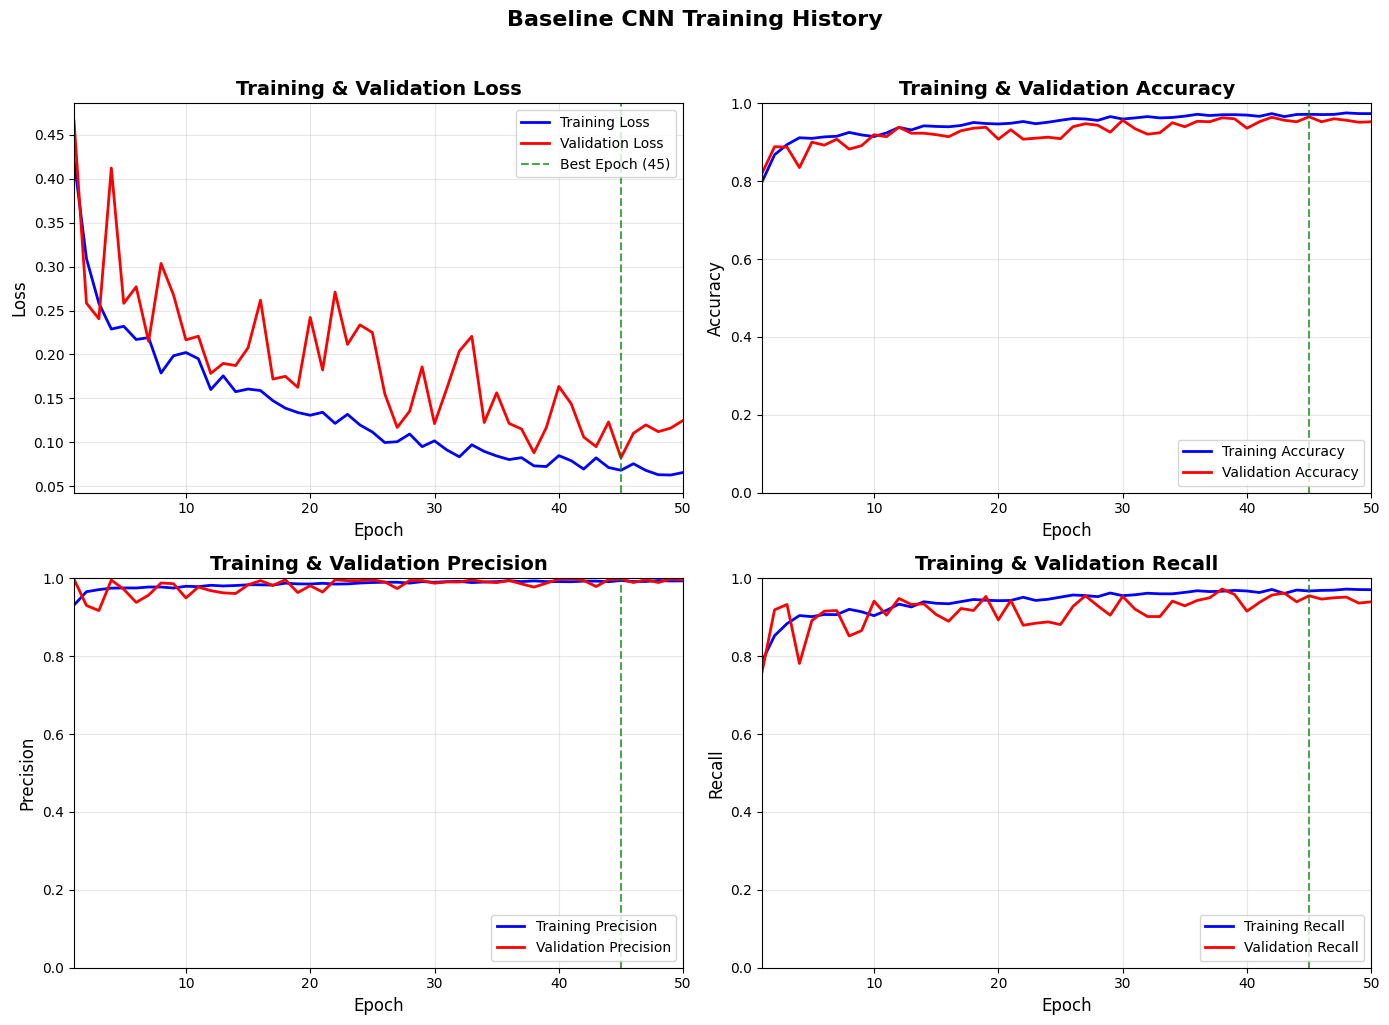

In [ ]:
def plot_training_history(history, save_path=None):
    """
    Create a 2×2 subplot showing training history metrics.
    
    Args:
        history: Keras History object from model.fit()
        save_path: Path to save the figure (optional)
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    epochs = range(1, len(history.history['loss']) + 1)
    
    # Plot 1: Training & Validation Loss
    ax1 = axes[0, 0]
    ax1.plot(epochs, history.history['loss'], 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, history.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend(loc='upper right', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([1, len(epochs)])
    
    # Mark best epoch
    best_epoch = np.argmin(history.history['val_loss']) + 1
    ax1.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
    ax1.legend(loc='upper right', fontsize=10)
    
    # Plot 2: Training & Validation Accuracy
    ax2 = axes[0, 1]
    ax2.plot(epochs, history.history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, history.history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
    ax2.set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.legend(loc='lower right', fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim([1, len(epochs)])
    ax2.set_ylim([0, 1])
    ax2.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7)
    
    # Plot 3: Precision
    ax3 = axes[1, 0]
    ax3.plot(epochs, history.history['precision'], 'b-', label='Training Precision', linewidth=2)
    ax3.plot(epochs, history.history['val_precision'], 'r-', label='Validation Precision', linewidth=2)
    ax3.set_title('Training & Validation Precision', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Epoch', fontsize=12)
    ax3.set_ylabel('Precision', fontsize=12)
    ax3.legend(loc='lower right', fontsize=10)
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim([1, len(epochs)])
    ax3.set_ylim([0, 1])
    ax3.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7)
    
    # Plot 4: Recall
    ax4 = axes[1, 1]
    ax4.plot(epochs, history.history['recall'], 'b-', label='Training Recall', linewidth=2)
    ax4.plot(epochs, history.history['val_recall'], 'r-', label='Validation Recall', linewidth=2)
    ax4.set_title('Training & Validation Recall', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Epoch', fontsize=12)
    ax4.set_ylabel('Recall', fontsize=12)
    ax4.legend(loc='lower right', fontsize=10)
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim([1, len(epochs)])
    ax4.set_ylim([0, 1])
    ax4.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7)
    
    plt.suptitle('Baseline CNN Training History', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Training history plot saved to: {save_path}")
    
    plt.show()
    
    return fig


# Plot and save training history
fig = plot_training_history(history, save_path=RESULTS_DIR / 'training_history.png')

## 1.9 Evaluate on Test Set

In [ ]:
# Load the best model from checkpoint
best_model_path = RESULTS_DIR / 'best_model.h5'

if best_model_path.exists():
    print(f"Loading best model from: {best_model_path}")
    best_model = load_model(best_model_path)
    print("Best model loaded successfully")
else:
    print("Best model checkpoint not found. Using current model.")
    best_model = model

Loading best model from: ../results/models/baseline_cnn/best_model.h5
Best model loaded successfully


In [ ]:
# Reset test generator
test_generator.reset()

# Make predictions on test set
print("\nMaking predictions on test set...")
y_pred_proba = best_model.predict(test_generator, verbose=1)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Get true labels
y_true = test_generator.classes

print(f"\nPredictions shape: {y_pred.shape}")
print(f"True labels shape: {y_true.shape}")


Making predictions on test set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 163ms/step

Predictions shape: (624,)
True labels shape: (624,)


In [ ]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\n" + "=" * 60)
print("TEST SET EVALUATION METRICS")
print("=" * 60)

print(f"\nOverall Metrics:")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")


TEST SET EVALUATION METRICS

Overall Metrics:
  Accuracy:  0.8510 (85.10%)
  Precision: 0.8180
  Recall:    0.9795
  F1-Score:  0.8915


In [ ]:
# Generate classification report
class_names = ['NORMAL', 'PNEUMONIA']

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      NORMAL       0.95      0.64      0.76       234
   PNEUMONIA       0.82      0.98      0.89       390

    accuracy                           0.85       624
   macro avg       0.88      0.81      0.83       624
weighted avg       0.87      0.85      0.84       624



In [ ]:
# Save metrics to text file
metrics_path = RESULTS_DIR / 'metrics.txt'

with open(metrics_path, 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("BASELINE CNN - TEST SET EVALUATION METRICS\n")
    f.write("=" * 60 + "\n\n")
    
    f.write(f"Evaluation Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    
    f.write("Overall Metrics:\n")
    f.write(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)\n")
    f.write(f"  Precision: {precision:.4f}\n")
    f.write(f"  Recall:    {recall:.4f}\n")
    f.write(f"  F1-Score:  {f1:.4f}\n\n")
    
    f.write("Classification Report:\n")
    f.write(report)
    
print(f"Metrics saved to: {metrics_path}")

Metrics saved to: ../results/models/baseline_cnn/metrics.txt


## 1.10 Confusion Matrix

Confusion matrix saved to: ../results/models/baseline_cnn/confusion_matrix.png


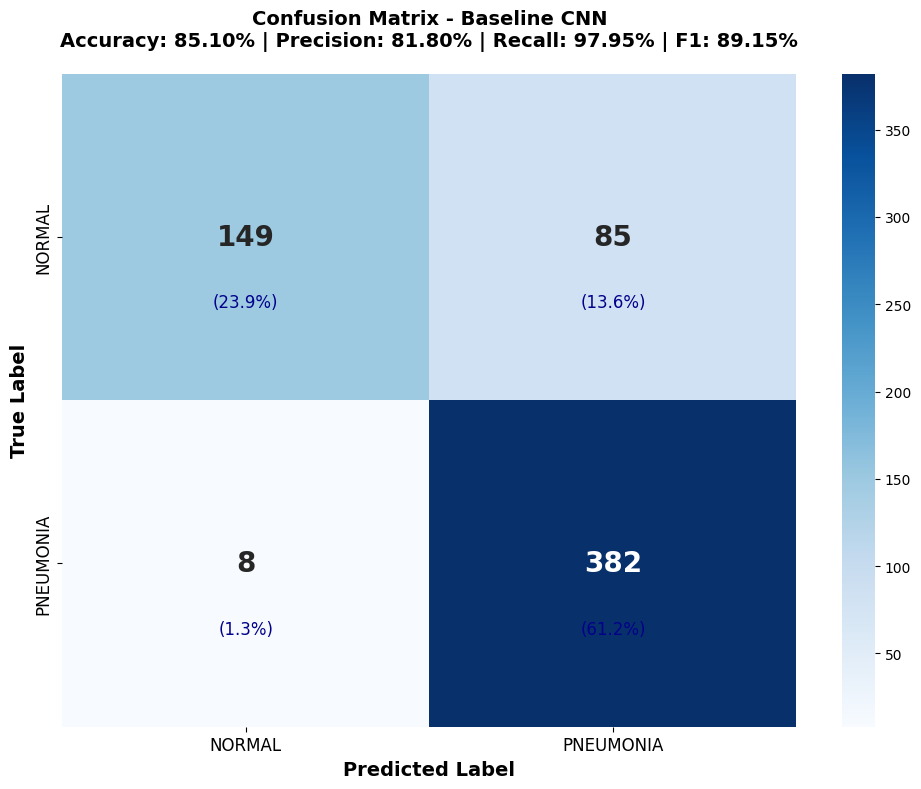

In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_names, metrics, save_path=None):
    """
    Create a confusion matrix heatmap with metrics in the title.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        class_names: List of class names
        metrics: Dictionary with accuracy, precision, recall, f1
        save_path: Path to save the figure (optional)
    """
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create heatmap
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        annot_kws={'size': 20, 'fontweight': 'bold'},
        ax=ax
    )
    
    # Labels and title
    ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=14, fontweight='bold')
    ax.tick_params(axis='both', labelsize=12)
    
    # Add metrics to title
    title = f"Confusion Matrix - Baseline CNN\n"
    title += f"Accuracy: {metrics['accuracy']:.2%} | "
    title += f"Precision: {metrics['precision']:.2%} | "
    title += f"Recall: {metrics['recall']:.2%} | "
    title += f"F1: {metrics['f1']:.2%}"
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    # Add counts as percentages too
    total = cm.sum()
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            percentage = cm[i, j] / total * 100
            ax.text(
                j + 0.5, i + 0.7, 
                f'({percentage:.1f}%)', 
                ha='center', va='center', 
                fontsize=12, color='darkblue'
            )
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Confusion matrix saved to: {save_path}")
    
    plt.show()
    
    return cm, fig


# Create metrics dictionary
metrics_dict = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1
}

# Plot and save confusion matrix
cm, fig = plot_confusion_matrix(
    y_true, y_pred, 
    class_names, 
    metrics_dict,
    save_path=RESULTS_DIR / 'confusion_matrix.png'
)

In [ ]:
# Analyze confusion matrix
print("\n" + "=" * 60)
print("CONFUSION MATRIX ANALYSIS")
print("=" * 60)

tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix Values:")
print(f"  True Negatives (NORMAL correctly classified):  {tn}")
print(f"  False Positives (NORMAL misclassified as PNEUMONIA): {fp}")
print(f"  False Negatives (PNEUMONIA misclassified as NORMAL): {fn}")
print(f"  True Positives (PNEUMONIA correctly classified): {tp}")

# Calculate specificity
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\nAdditional Metrics:")
print(f"  Specificity (TNR): {specificity:.4f}")
print(f"  Sensitivity (TPR/Recall): {recall:.4f}")

# Clinical interpretation
print(f"\nClinical Interpretation:")
print(f"  - {fn} pneumonia cases were missed (False Negatives) - Critical!")
print(f"  - {fp} normal cases were incorrectly flagged as pneumonia (False Positives)")


CONFUSION MATRIX ANALYSIS

Confusion Matrix Values:
  True Negatives (NORMAL correctly classified):  149
  False Positives (NORMAL misclassified as PNEUMONIA): 85
  False Negatives (PNEUMONIA misclassified as NORMAL): 8
  True Positives (PNEUMONIA correctly classified): 382

Additional Metrics:
  Specificity (TNR): 0.6368
  Sensitivity (TPR/Recall): 0.9795

Clinical Interpretation:
  - 8 pneumonia cases were missed (False Negatives) - Critical!
  - 85 normal cases were incorrectly flagged as pneumonia (False Positives)


## 1.11 Save Model and Results

In [ ]:
# Save final model
final_model_path = RESULTS_DIR / 'final_model.h5'
model.save(final_model_path)
print(f"Final model saved to: {final_model_path}")

Final model saved to: ../results/models/baseline_cnn/final_model.h5


In [ ]:
# Save training history as JSON
history_path = RESULTS_DIR / 'training_history.json'

# Convert history to serializable format
history_dict = {}
for key, value in history.history.items():
    history_dict[key] = [float(v) for v in value]

with open(history_path, 'w') as f:
    json.dump(history_dict, f, indent=2)

print(f"Training history saved to: {history_path}")

Training history saved to: ../results/models/baseline_cnn/training_history.json


In [ ]:
# Create comprehensive summary file
summary_path = RESULTS_DIR / 'model_summary.txt'

# Capture model summary
import io
stream = io.StringIO()
model.summary(print_fn=lambda x: stream.write(x + '\n'))
model_summary_str = stream.getvalue()

with open(summary_path, 'w') as f:
    f.write("=" * 70 + "\n")
    f.write("BASELINE CNN MODEL - COMPLETE SUMMARY\n")
    f.write("=" * 70 + "\n\n")
    
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    
    # Model Architecture
    f.write("-" * 70 + "\n")
    f.write("MODEL ARCHITECTURE\n")
    f.write("-" * 70 + "\n")
    f.write(model_summary_str)
    f.write("\n")
    
    # Training Parameters
    f.write("-" * 70 + "\n")
    f.write("TRAINING PARAMETERS\n")
    f.write("-" * 70 + "\n")
    f.write(f"Image size: {IMG_SIZE}x{IMG_SIZE}\n")
    f.write(f"Batch size: {BATCH_SIZE}\n")
    f.write(f"Max epochs: {EPOCHS}\n")
    f.write(f"Initial learning rate: {LEARNING_RATE}\n")
    f.write(f"Optimizer: Adam\n")
    f.write(f"Loss function: Binary Crossentropy\n")
    f.write(f"Class weights: {class_weight_dict}\n\n")
    
    # Data Augmentation
    f.write("-" * 70 + "\n")
    f.write("DATA AUGMENTATION\n")
    f.write("-" * 70 + "\n")
    for param, value in augmentation_params.items():
        f.write(f"{param}: {value}\n")
    f.write("\n")
    
    # Training Results
    f.write("-" * 70 + "\n")
    f.write("TRAINING RESULTS\n")
    f.write("-" * 70 + "\n")
    f.write(f"Total epochs trained: {len(history.history['loss'])}\n")
    f.write(f"Best epoch: {best_epoch}\n")
    f.write(f"Best validation loss: {best_val_loss:.4f}\n")
    f.write(f"Best validation accuracy: {best_val_acc:.4f}\n\n")
    
    # Test Set Metrics
    f.write("-" * 70 + "\n")
    f.write("TEST SET EVALUATION\n")
    f.write("-" * 70 + "\n")
    f.write(f"Test samples: {test_generator.samples}\n")
    f.write(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall:    {recall:.4f}\n")
    f.write(f"F1-Score:  {f1:.4f}\n")
    f.write(f"Specificity: {specificity:.4f}\n\n")
    
    # Confusion Matrix
    f.write("-" * 70 + "\n")
    f.write("CONFUSION MATRIX\n")
    f.write("-" * 70 + "\n")
    f.write(f"True Negatives:  {tn}\n")
    f.write(f"False Positives: {fp}\n")
    f.write(f"False Negatives: {fn}\n")
    f.write(f"True Positives:  {tp}\n\n")
    
    # Classification Report
    f.write("-" * 70 + "\n")
    f.write("CLASSIFICATION REPORT\n")
    f.write("-" * 70 + "\n")
    f.write(report)
    f.write("\n")
    
    # Output Files
    f.write("-" * 70 + "\n")
    f.write("OUTPUT FILES\n")
    f.write("-" * 70 + "\n")
    f.write(f"Best model: {RESULTS_DIR / 'best_model.h5'}\n")
    f.write(f"Final model: {RESULTS_DIR / 'final_model.h5'}\n")
    f.write(f"Training history: {RESULTS_DIR / 'training_history.json'}\n")
    f.write(f"Training plots: {RESULTS_DIR / 'training_history.png'}\n")
    f.write(f"Confusion matrix: {RESULTS_DIR / 'confusion_matrix.png'}\n")
    f.write(f"Metrics: {RESULTS_DIR / 'metrics.txt'}\n")

print(f"Model summary saved to: {summary_path}")

Model summary saved to: ../results/models/baseline_cnn/model_summary.txt


In [ ]:
# Print final summary
print("\n" + "=" * 70)
print("BASELINE CNN TRAINING COMPLETE")
print("=" * 70)

print(f"\nModel Performance Summary:")
print(f"  Test Accuracy:  {accuracy:.2%}")
print(f"  Test Precision: {precision:.2%}")
print(f"  Test Recall:    {recall:.2%}")
print(f"  Test F1-Score:  {f1:.2%}")

print(f"\nOutput Files Generated:")
output_files = [
    'best_model.h5',
    'final_model.h5',
    'training_history.json',
    'training_history.png',
    'confusion_matrix.png',
    'metrics.txt',
    'model_summary.txt'
]

for f in output_files:
    filepath = RESULTS_DIR / f
    status = "OK" if filepath.exists() else "MISSING"
    print(f"  [{status}] {filepath}")

print(f"\nThis baseline CNN model serves as the performance reference.")
print(f"Next steps: Implement VGG16 and ResNet50 transfer learning models.")


BASELINE CNN TRAINING COMPLETE

Model Performance Summary:
  Test Accuracy:  85.10%
  Test Precision: 81.80%
  Test Recall:    97.95%
  Test F1-Score:  89.15%

Output Files Generated:
  [OK] ../results/models/baseline_cnn/best_model.h5
  [OK] ../results/models/baseline_cnn/final_model.h5
  [OK] ../results/models/baseline_cnn/training_history.json
  [OK] ../results/models/baseline_cnn/training_history.png
  [OK] ../results/models/baseline_cnn/confusion_matrix.png
  [OK] ../results/models/baseline_cnn/metrics.txt
  [OK] ../results/models/baseline_cnn/model_summary.txt

This baseline CNN model serves as the performance reference.
Next steps: Implement VGG16 and ResNet50 transfer learning models.


---
# Part 2: VGG16 Transfer Learning

## 2.1 Imports

In [18]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers

In [ ]:
VGG16_RESULTS_DIR = Path('../results/models/vgg16')
VGG16_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## 2.2 VGG16 Architecture

In [ ]:
vgg_base = VGG16(weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
vgg_base.trainable = False # Congela as camadas convolucionais

# 2. Montar o modelo final
model_vgg = Sequential([
    vgg_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
], name="VGG16_Pneumonia_Model")

model_vgg.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

model_vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "VGG16_Pneumonia_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 2.3 Train the model

In [ ]:
# Callbacks para salvar o melhor modelo e evitar overfitting
vgg_callbacks = [
    EarlyStopping(monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(VGG16_RESULTS_DIR / 'best_vgg16_model.keras',
          save_best_only=True
    ),
    ReduceLROnPlateau(monitor='val_loss',
        factor=0.2,
        patience=3
    )
]

vgg_history = model_vgg.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    class_weight=class_weight_dict, # O peso das classes para lidar com o desbalanceamento
    callbacks=vgg_callbacks
)

Epoch 1/25
139/139 ━━━━━━━━━━━━━━━━━━━━ 508s 4s/step - accuracy: 0.8678 - loss: 0.3501 - precision: 0.9656 - recall: 0.8525 - val_accuracy: 0.8504 - val_loss: 0.3548 - val_precision: 0.9813 - val_recall: 0.8141 - learning_rate: 1.0000e-04
Epoch 2/25
139/139 ━━━━━━━━━━━━━━━━━━━━ 522s 4s/step - accuracy: 0.8796 - loss: 0.3219 - precision: 0.9729 - recall: 0.8619 - val_accuracy: 0.8619 - val_loss: 0.3326 - val_precision: 0.9856 - val_recall: 0.8262 - learning_rate: 1.0000e-04
Epoch 3/25
139/139 ━━━━━━━━━━━━━━━━━━━━ 514s 4s/step - accuracy: 0.8796 - loss: 0.3082 - precision: 0.9700 - recall: 0.8646 - val_accuracy: 0.8824 - val_loss: 0.3015 - val_precision: 0.9939 - val_recall: 0.8468 - learning_rate: 1.0000e-04
Epoch 4/25
139/139 ━━━━━━━━━━━━━━━━━━━━ 514s 4s/step - accuracy: 0.8904 - loss: 0.2837 - precision: 0.9743 - recall: 0.8755 - val_accuracy: 0.8887 - val_loss: 0.2851 - val_precision: 0.9901 - val_recall: 0.8589 - learning_rate: 1.0000e-04
Epoch 5/25
139/139 ━━━━━━━━━━━━━━━━━━━━ 510s

In [23]:
# Avaliação final
test_results = model_vgg.evaluate(test_generator)
print(f"Test Accuracy: {test_results[1]:.4f}")
print(f"Test Recall: {test_results[3]:.4f}") # Muito importante para pneumonia!

metrics_names = model_vgg.metrics_names
for name, value in zip(metrics_names, test_results):
    print(f"{name.capitalize()}: {value:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 71s 4s/step - accuracy: 0.8381 - loss: 0.3753 - precision: 0.8793 - recall: 0.8590
Test Accuracy: 0.8381
Test Recall: 0.8590
Loss: 0.3753
Compile_metrics: 0.8381


## 2.4 Plot Training History

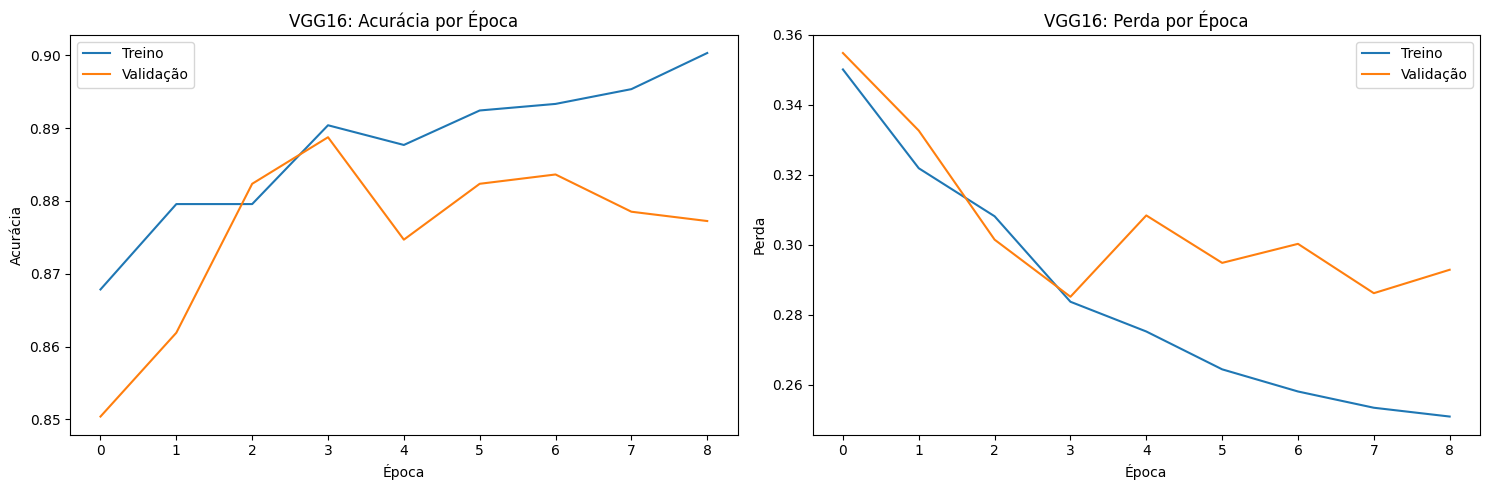

In [ ]:
def plot_vgg16_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    
    # Gráfico de Precisão (Accuracy)
    ax[0].plot(history.history['accuracy'], label='Train')
    ax[0].plot(history.history['val_accuracy'], label='Validation')
    ax[0].set_title('VGG16: Epoch Accuracy')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Accuracy')
    ax[0].legend()
    
    # Gráfico de Perda (Loss)
    ax[1].plot(history.history['loss'], label='Train')
    ax[1].plot(history.history['val_loss'], label='Validation')
    ax[1].set_title('VGG16: Epoch Loss')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Loss')
    ax[1].legend()
    
    plt.tight_layout()
    plt.savefig(VGG16_RESULTS_DIR / 'vgg16_learning_curves.png')
    plt.show()

plot_vgg16_history(vgg_history)

## 2.5 Confusion Matrix

20/20 ━━━━━━━━━━━━━━━━━━━━ 73s 4s/step


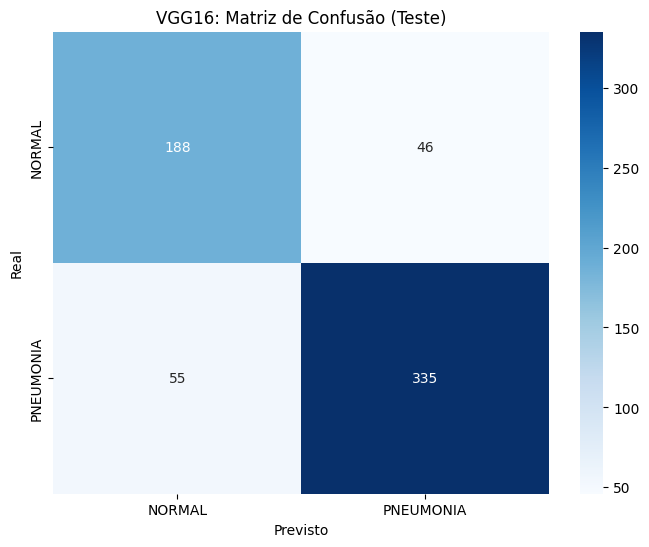


Relatório de Classificação VGG16:
              precision    recall  f1-score   support

      NORMAL       0.77      0.80      0.79       234
   PNEUMONIA       0.88      0.86      0.87       390

    accuracy                           0.84       624
   macro avg       0.83      0.83      0.83       624
weighted avg       0.84      0.84      0.84       624



In [25]:
# 1. Resetar o gerador de teste para garantir a ordem correta
test_generator.reset()

# 2. Obter as previsões (probabilidades)
preds = model_vgg.predict(test_generator)
# Converter probabilidades para classes (0 ou 1) usando o limiar de 0.5
y_pred = (preds > 0.5).astype(int).flatten()

# 3. Obter as etiquetas reais
y_true = test_generator.classes

# 4. Gerar a Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)
labels = ['NORMAL', 'PNEUMONIA']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('VGG16: Matriz de Confusão (Teste)')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.savefig(VGG16_RESULTS_DIR / 'vgg16_confusion_matrix.png')
plt.show()

# 5. Exibir o Relatório de Classificação
print("\nRelatório de Classificação VGG16:")
print(classification_report(y_true, y_pred, target_names=labels))

---
# Part 3: ResNet50 Transfer Learning

*To be implemented...*

---
# Part 4: Ensemble Model

*To be implemented...*